##TASK 1 — IRIS FLOWER CLASSIFICATION

###Markdown: Title

# Iris Flower Classification

### CodeAlpha Data Science Internship — Task 1

**Objective:**  
Build a machine learning classification model that predicts the species of an Iris flower based on its sepal and petal measurements.

**Iris Species:**
- Setosa
- Versicolor
- Virginica

**Tools & Technologies:**  
Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

###Markdown: Introduction

## Introduction

The Iris Flower Classification project is a supervised machine learning problem
in which the species of an Iris flower is predicted from its physical measurements.

The dataset contains four important features:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The target variable represents the species of the flower:
Setosa, Versicolor, or Virginica.

In this project, the dataset will be explored, visualized, preprocessed,
and used to train a classification model. The performance of the model
will then be evaluated using appropriate classification metrics.

###Importing Libraries

In [ ]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


###Loading the Dataset

In [ ]:
from google.colab import files

# Download a single file
files.download('Iris.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###Understanding the Dataset

In [ ]:
import pandas as pd
import io

# Assuming 'uploaded' dict is available from previous execution
# Load the dataset into df
df = pd.read_csv(io.BytesIO(uploaded['Iris (3).csv']))

# Display dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 150
Number of columns: 6


In [ ]:
# Display column names

print("Column Names:")
print(df.columns.tolist())

Column Names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


In [ ]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
# Statistical summary

df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


###Checking Missing Values

In [ ]:
# Check for missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [ ]:
# Check duplicate records

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


###Exploring the Target Variable

In [ ]:
# Count each Iris species

species_counts = df["Species"].value_counts()

print(species_counts)

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


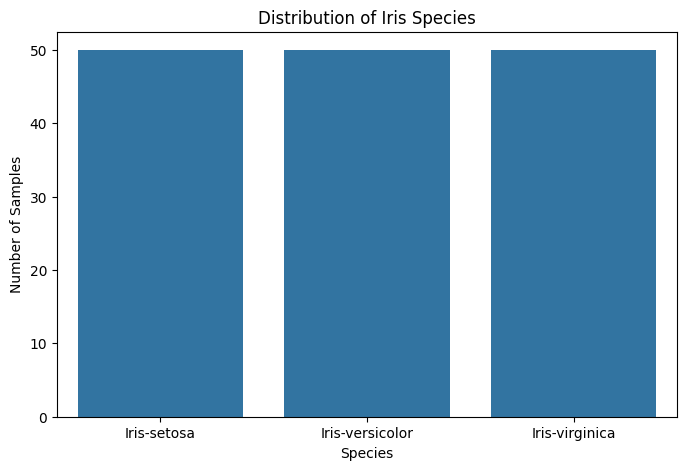

In [ ]:
# Visualize species distribution

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Species")

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Number of Samples")

plt.show()

###Feature Distribution

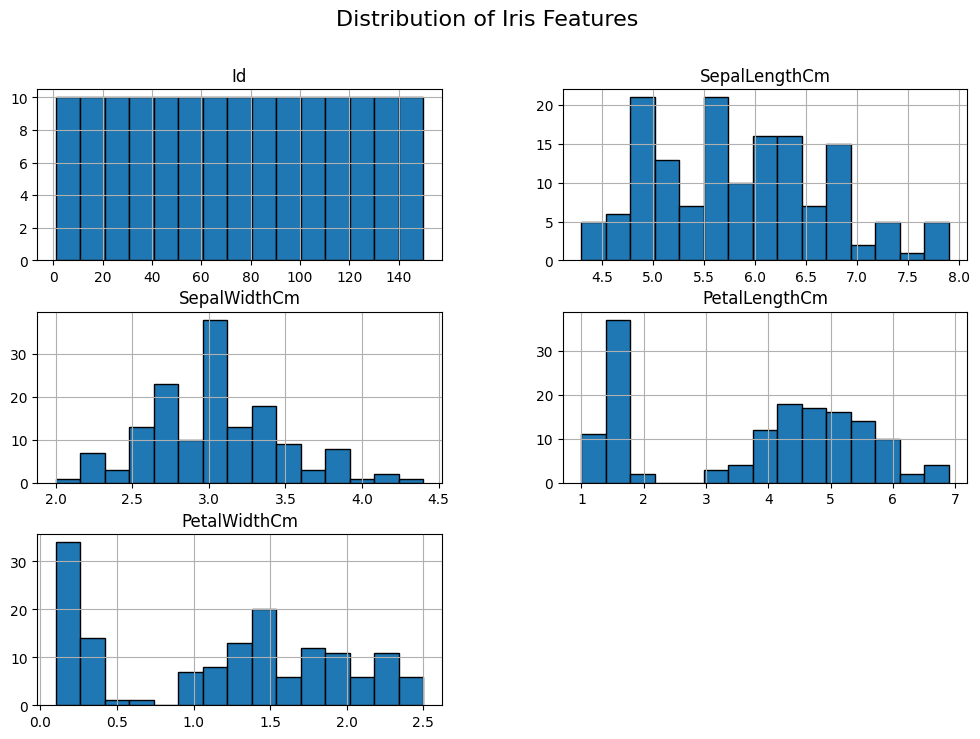

In [ ]:
# Plot distributions of numerical features

df.hist(
    figsize=(12, 8),
    bins=15,
    edgecolor="black"
)

plt.suptitle("Distribution of Iris Features", fontsize=16)

plt.show()

###Comparing Features by Species

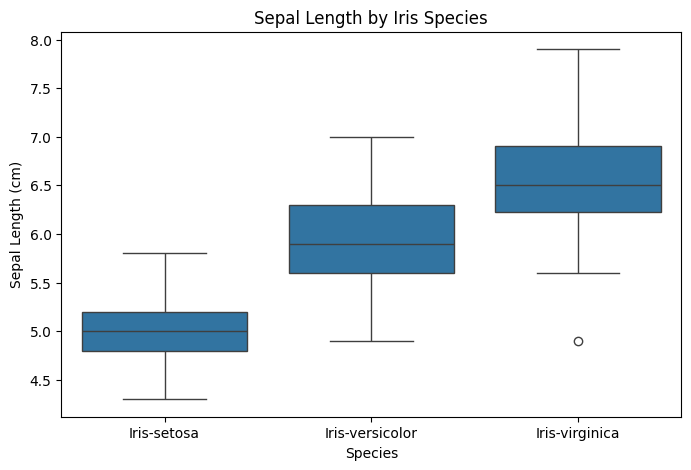

In [ ]:
# Sepal Length by species

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Species",
    y="SepalLengthCm"
)

plt.title("Sepal Length by Iris Species")
plt.xlabel("Species")
plt.ylabel("Sepal Length (cm)")

plt.show()

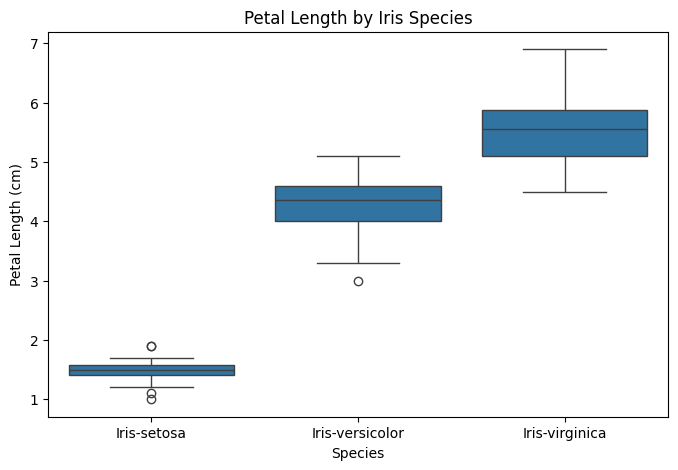

In [ ]:
# Petal Length by species

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Species",
    y="PetalLengthCm"
)

plt.title("Petal Length by Iris Species")
plt.xlabel("Species")
plt.ylabel("Petal Length (cm)")

plt.show()

###Scatter Plot

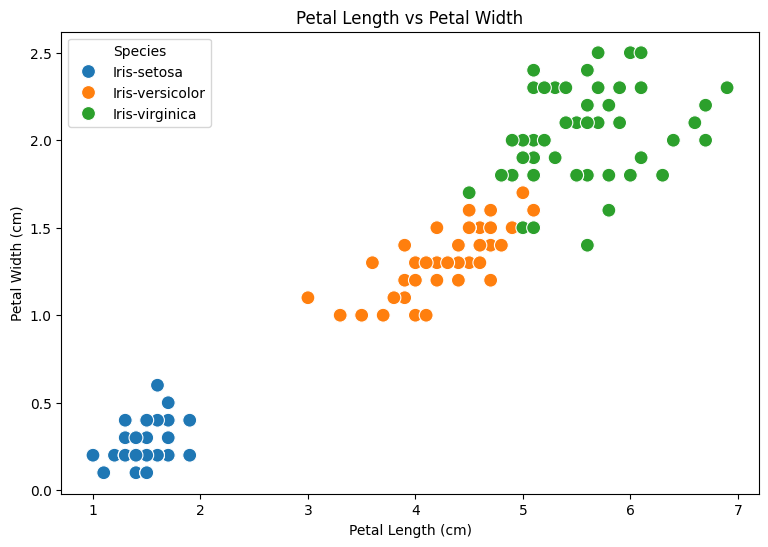

In [ ]:
# Petal length vs petal width

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="PetalLengthCm",
    y="PetalWidthCm",
    hue="Species",
    s=100
)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")

plt.show()

###Correlation Analysis

In [ ]:
# Select numerical columns

numerical_df = df.drop(columns=["Id", "Species"])

# Calculate correlation matrix

correlation_matrix = numerical_df.corr()

correlation_matrix

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


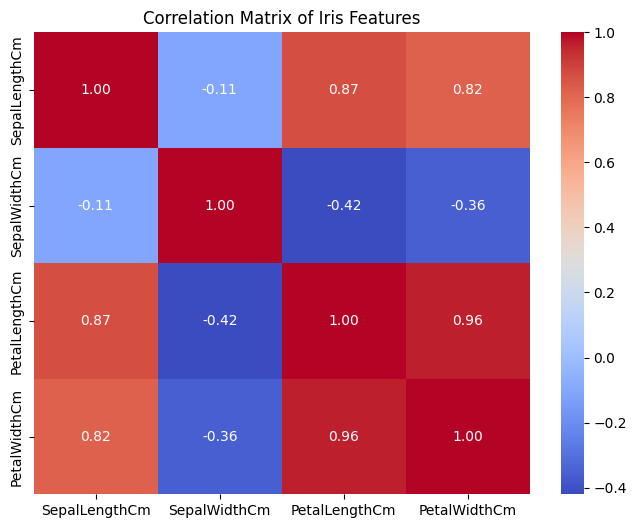

In [ ]:
# Visualize correlation matrix

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Iris Features")

plt.show()

###Preparing Data for Machine Learning

In [ ]:
# Separate features and target

X = df.drop(columns=["Id", "Species"]) # Also dropping 'Id' as it is not a feature
y = df["Species"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (150, 4)
Target shape: (150,)


###Train-Test S[pliting

In [ ]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


We're using 80% for training and 20% for testing.

###Feature Scaling

In [ ]:
# Standardize the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


###Training the Classification Model

In [ ]:
# Create Logistic Regression model

model = LogisticRegression(
    max_iter=200,
    random_state=42
)

# Train the model

model.fit(X_train_scaled, y_train)

print("Model training completed successfully!")

Model training completed successfully!


###Making Predictions

In [ ]:
# Predict species for test data

y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred)

Predictions:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']


###Calculating Accuracy

In [ ]:
# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 93.33%


###Classification Report

In [ ]:
# Generate classification report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



###Confusion Matrix

In [ ]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


<Figure size 700x500 with 0 Axes>

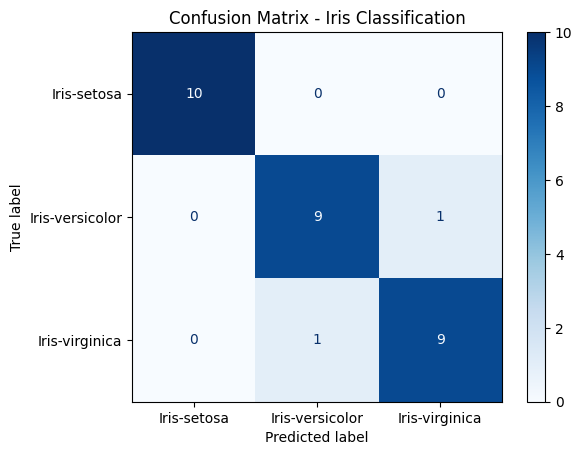

In [ ]:
# Visualize confusion matrix

plt.figure(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Iris Classification")

plt.show()

###Testing the Model with a new Flower

In [ ]:
# Example new flower measurement

new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

# Scale the new data
new_flower_scaled = scaler.transform(new_flower)

# Predict species
prediction = model.predict(new_flower_scaled)

print("Predicted Iris Species:", prediction[0])

Predicted Iris Species: Iris-setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


###Comparing Actual VS Predicted

In [ ]:
# Create comparison DataFrame

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,Iris-setosa,Iris-setosa
1,Iris-virginica,Iris-virginica
2,Iris-versicolor,Iris-versicolor
3,Iris-versicolor,Iris-versicolor
4,Iris-setosa,Iris-setosa
5,Iris-versicolor,Iris-versicolor
6,Iris-setosa,Iris-setosa
7,Iris-setosa,Iris-setosa
8,Iris-virginica,Iris-virginica
9,Iris-versicolor,Iris-versicolor


###Final Model Summary

In [ ]:
print("========== MODEL SUMMARY ==========")
print("Algorithm       : Logistic Regression")
print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))
print(f"Accuracy        : {accuracy * 100:.2f}%")
print("===================================")

========== MODEL SUMMARY ==========
Algorithm       : Logistic Regression
Training Samples: 120
Testing Samples : 30
Accuracy        : 93.33%


###Conclusion

In this project, an Iris Flower Classification model was developed using
the Iris dataset and Logistic Regression.

The dataset was first explored and analyzed to understand its structure,
feature distributions, species distribution, and relationships between
numerical features. The data was then divided into training and testing
sets and standardized before model training.

The Logistic Regression model was trained using the four flower
measurements and evaluated using accuracy, precision, recall, F1-score,
and a confusion matrix.

The results demonstrate that machine learning can effectively classify
Iris flower species based on their physical measurements.

### Key Takeaways

- The Iris dataset contains three flower species.
- Four numerical measurements were used as predictive features.
- Exploratory Data Analysis helped understand feature relationships.
- Feature scaling was applied before model training.
- Logistic Regression was used for classification.
- Model performance was evaluated using multiple classification metrics.
- The trained model can predict the species of a new Iris flower.